# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>
## <span style="color:blue">  Numerical exercises 7</span>

### Exercise 07.1
In the NSL simulator code we have provided, include tail corrections for potential energy, $U$, and pressure $P$.

A causa del cutoff sferico delle simulazioni, è utile implementare le cosiddette **correzioni di coda** al fine di compensare la parte mancante a long-range del potenziale. Nelle regioni in cui $r > r_c$, assumiamo che $g(r) = 1$ (il sistema si comporta come un gas perfetto). 

$$ \frac{\langle V_{LJ} \rangle_{\text{tail}}}{N} = \frac{8\pi\rho_{LJ}\varepsilon}{9r_{c(LJ)}^9} - \frac{8\pi\rho_{LJ}\varepsilon}{3r_{c(LJ)}^3} $$

$$ \frac{\langle W_{LJ} \rangle_{\text{tail}}}{3N\varepsilon} = 32\pi\rho_{LJ} \left[ \frac{1}{9r_{c(LJ)}^9} - \frac{1}{6r_{c(LJ)}^3} \right] $$

### Exercise 07.2

Use the NSL simulator code to <span style="color:red">print out **instantaneous** values of potential energy per particle, $U/N$, along **equilibrated** Monte Carlo $(N,V,T)$ and Molecular Dynamics $(N,V,E)$ simulations</span> of $M=5\times 10^5$ MC steps or MD time steps (where, for MC, the Metropolis acceptance ratio should be fixed approximately to 50% by changing the value of $dt$ that, in the MC case, represent the amplitude of the step in each direction) in the following thermodynamic conditions:
- liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r^\star_c = 2.5$, for MD $dt^\star=0.001$)

Equilibration is needed both with MC and with MD. With MD, you will observe that starting from a perfect crystalline configuration the temperature, $T$, will not conserve its value. Explore and find the starting value of $T$ needed to stabilize, after a certain number of time steps (equilibration time), the average value of $T$ on the desired $T^\star$.
<span style="color:red">Perform your MC and MD simulations by re-starting after such equilibration time.</span>

## SIMULAZIONE MONTECARLO

Per quanto riguarda il metodo **Montecarlo**, partendo da una configurazione iniziale cristallina fcc, ho eseguito una fase di **equilibrazione** caratterizzata da **50.000 steps**.
Dopodichè ho inserito a configurazione finale dell'**output** della fase di equilibrazione nell'**input** della seguente fase di misura plottata, caratterzzata da **500.000 steps**.

In [2]:
import numpy as np
import re

def load_fixed_file(filename, usecols=1):
    fixed_lines = []
    with open(filename, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            
            fixed_line = re.sub(r'(?<=\d)(?=-\d)', ' ', line)
            fixed_lines.append(fixed_line)
            
    data = np.loadtxt(fixed_lines, usecols=usecols)
    return data

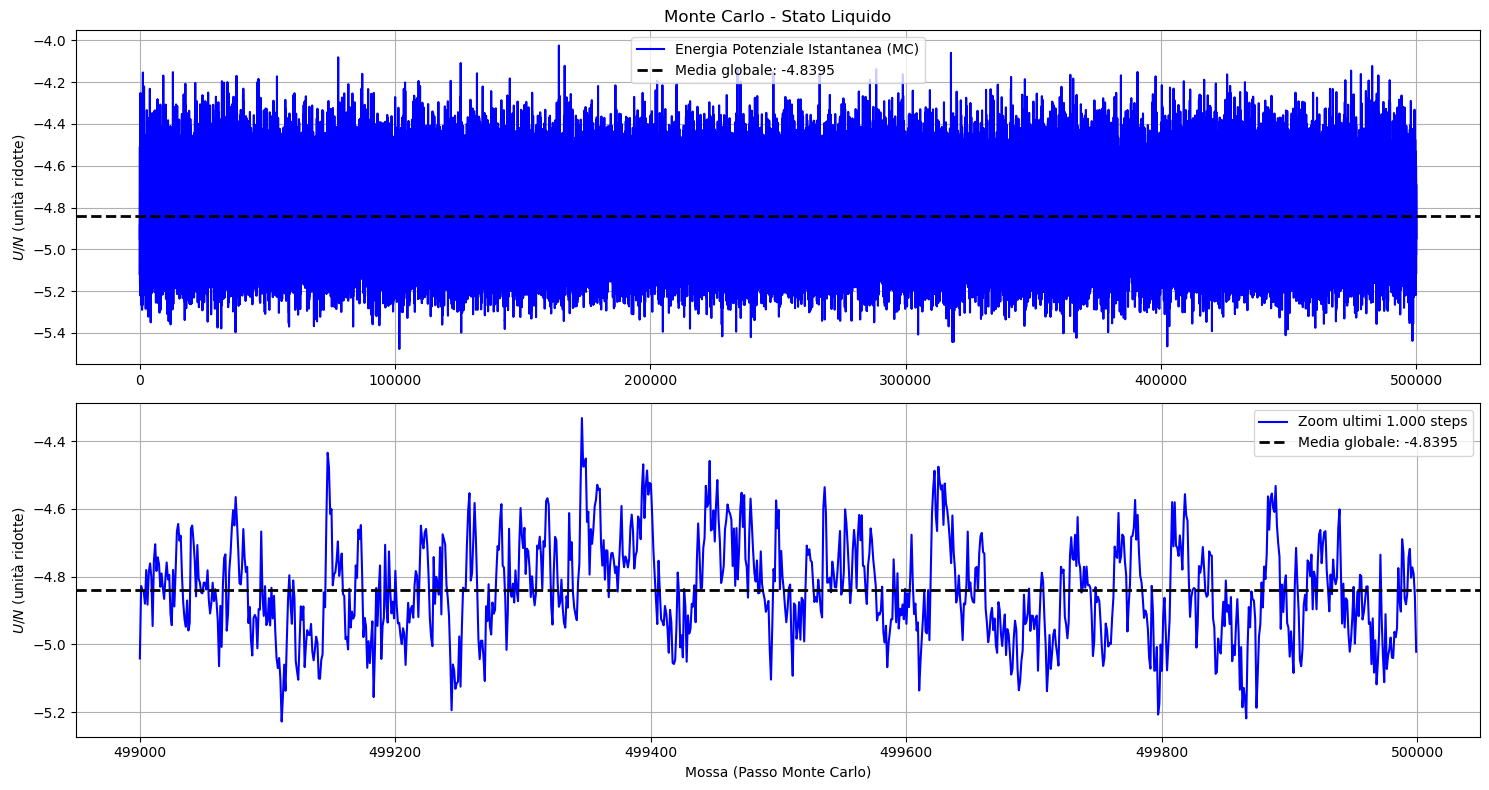

In [114]:
import numpy as np
import matplotlib.pyplot as plt

MC_path = "OUTPUT_MC"
epot_mc = np.loadtxt(MC_path + "/potential_energy.dat", usecols=1)
valore_medio = np.mean(epot_mc)
steps = np.arange(len(epot_mc))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))

ax1.plot(steps, epot_mc, label="Energia Potenziale Istantanea (MC)", color="blue")
ax1.axhline(y=valore_medio, color="black", linestyle="--", linewidth=2, label=f"Media globale: {valore_medio:.4f}")
ax1.set_ylabel(r"$U/N$ (unità ridotte)")
ax1.set_title("Monte Carlo - Stato Liquido")
ax1.grid(True)
ax1.legend()

zoom_start = -1000
ax2.plot(steps[zoom_start:], epot_mc[zoom_start:], label="Zoom ultimi 1.000 steps", color="blue")
ax2.axhline(y=valore_medio, color="black", linestyle="--", linewidth=2, label=f"Media globale: {valore_medio:.4f}")
ax2.set_xlabel("Mossa (Passo Monte Carlo)")
ax2.set_ylabel(r"$U/N$ (unità ridotte)")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

Ho plottato uno zoom degli ultimi 1.000 steps per evidenziare la **correlazione** dei dati. Infatti dal secondo grafico si nota chiaramente come i passi consecutivi non siano **statisticamente indipendenti**. Questo comportamento dei dati manifesta un tempo di autocorrelazione $\tau_{\text{corr}} > 1 \text{(step)}$

<span style="color:red"> **Non richiesto**. </span> Per essere sicuro della **convergenza** dell'energia potenziale della simulazione a un valore preciso ho plottato il valore della **media progressiva** della simulazione precendente. Effettivamente possiamo notare come vada a raggiungere un valore di convergenza ben definito all'aumentare degli steps della simulazione 

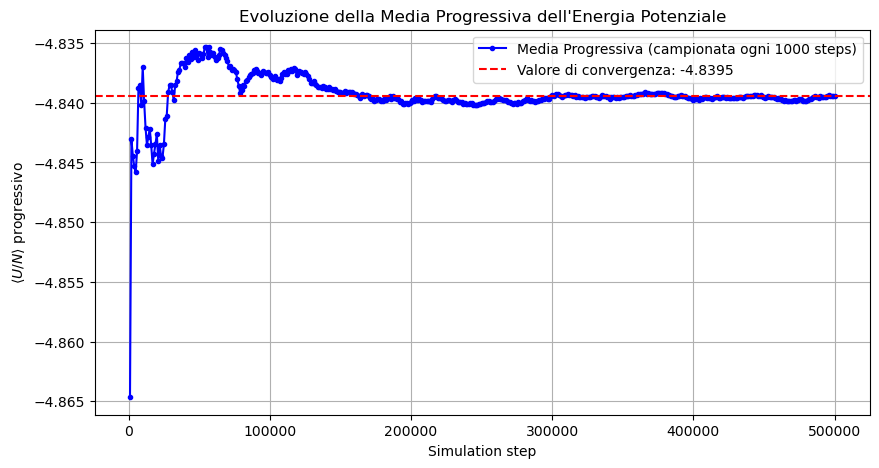

In [112]:
import numpy as np
import matplotlib.pyplot as plt

dati = epot_mc  
step_dim = 1000
punti_media = np.arange(step_dim, len(dati) + 1, step_dim)
media_progressiva = []
for n in punti_media:
    media_attuale = np.mean(dati[:n])
    media_progressiva.append(media_attuale)
media_progressiva = np.array(media_progressiva)

plt.figure(figsize=(10, 5))
plt.plot(punti_media, media_progressiva, marker='o', markersize=3, 
         linestyle='-', color='blue', label='Media Progressiva (campionata ogni 1000 steps)')
valore_finale = media_progressiva[-1]
plt.axhline(y=valore_finale, color='red', linestyle='--', label=f'Valore di convergenza: {valore_finale:.4f}')
plt.xlabel("Simulation step")
plt.ylabel(r"$\langle U/N \rangle$ progressivo")
plt.title("Evoluzione della Media Progressiva dell'Energia Potenziale")
plt.grid(True)
plt.legend()
plt.show()

## SIMULAZIONE DINAMICA MOLECOLARE

Ho eseguito la simulazione per **50.000 steps** per capire a che temperatura equilibrasse

Il valore medio della temperatura negli ultimi 400000 step è: 1.1110


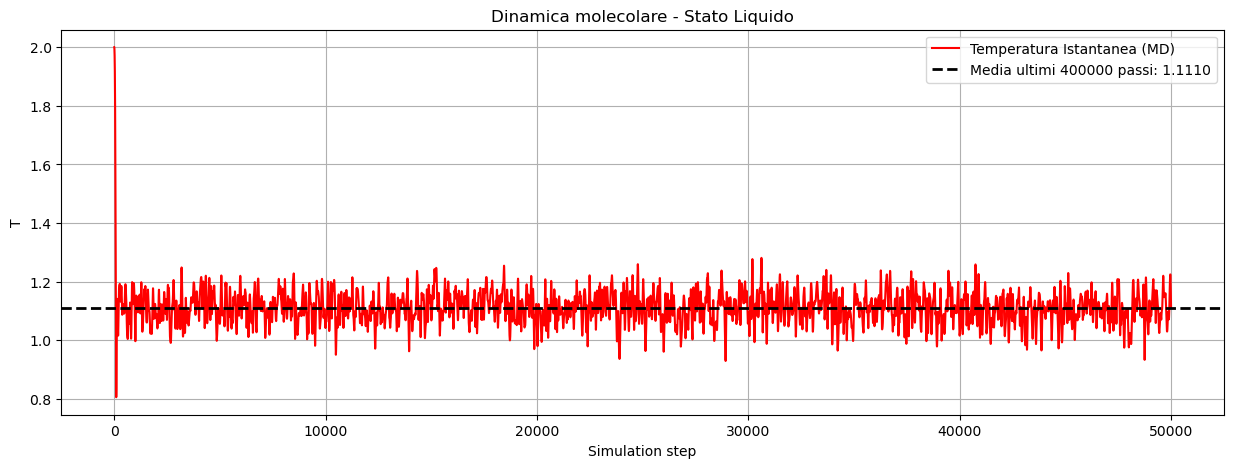

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# Carica i dati dal file della temperatura istantanea (MD)
T_md = load_fixed_file("OUTPUT_MD/MDtemperature_equilibration", usecols=1)

# Calcolo della media degli ultimi 40.000 dati
ultimi_dati = 400000
valore_medio_ultimi = np.mean(T_md[-ultimi_dati:])

# Stampa a schermo il valore numerico esatto
print(f"Il valore medio della temperatura negli ultimi {ultimi_dati} step è: {valore_medio_ultimi:.4f}")

plt.figure(figsize=(15, 5))

# Plot della curva della temperatura istantanea
plt.plot(T_md, label="Temperatura Istantanea (MD)", color="red")

# Disegna una linea orizzontale per mostrare visivamente la media trovata
plt.axhline(y=valore_medio_ultimi, color="black", linestyle="--", linewidth=2,
            label=f"Media ultimi {ultimi_dati} passi: {valore_medio_ultimi:.4f}")

plt.xlabel("Simulation step")
plt.ylabel("T")
plt.title("Dinamica molecolare - Stato Liquido")
plt.grid(True)
plt.legend()
plt.show()

Provando, la temperatura iniziale $\text{T}$ che permette di approssimare la temperatura target $\text{T*} = 1.1$ è $\text{T} = 1.9$.
In seguto ho inserito la **configurazione finale** di questa **fase di equilibrazione** come configurazione di input della simulazione successiva.
Chiaramente l'equilibrazione è stata raggiunta dopo 50.000 steps e anzi, potremmo dire che a occhio venga raggiunta ben prima (meno di 5.000 steps).


Il motivo per cui la temperatura non viene conservata è perchè con la simulazione di dinamica molecolare stiamo lavorando nell'**ensamble microcanonico (N,V,E)**. L'algoritmo di Verlet risolve l'equazione di Newton e mantiene l'energia totale E costante. Il sistema si trova inizialmente (l'ho imposto io) in una configurazione che non è termodinamicamente stabile, ovvero quella del cristallo fcc. Infatti nella consegna è richiesto un sistema in fase liquida. Dunque il cristallo iniziale "fonde" e il sistema diventa un liquido disordinato. Le particelle del sistema in questo liquido raggiungono distanze più "sfavorevoli", facendo sì che l'energia potenziale aumenti. Per la conservazione dell'energia totale l'energia cinetica diminuisce e di conseguenza anche la temperatura, dal momento che $E_K \sim k_B \, T$.

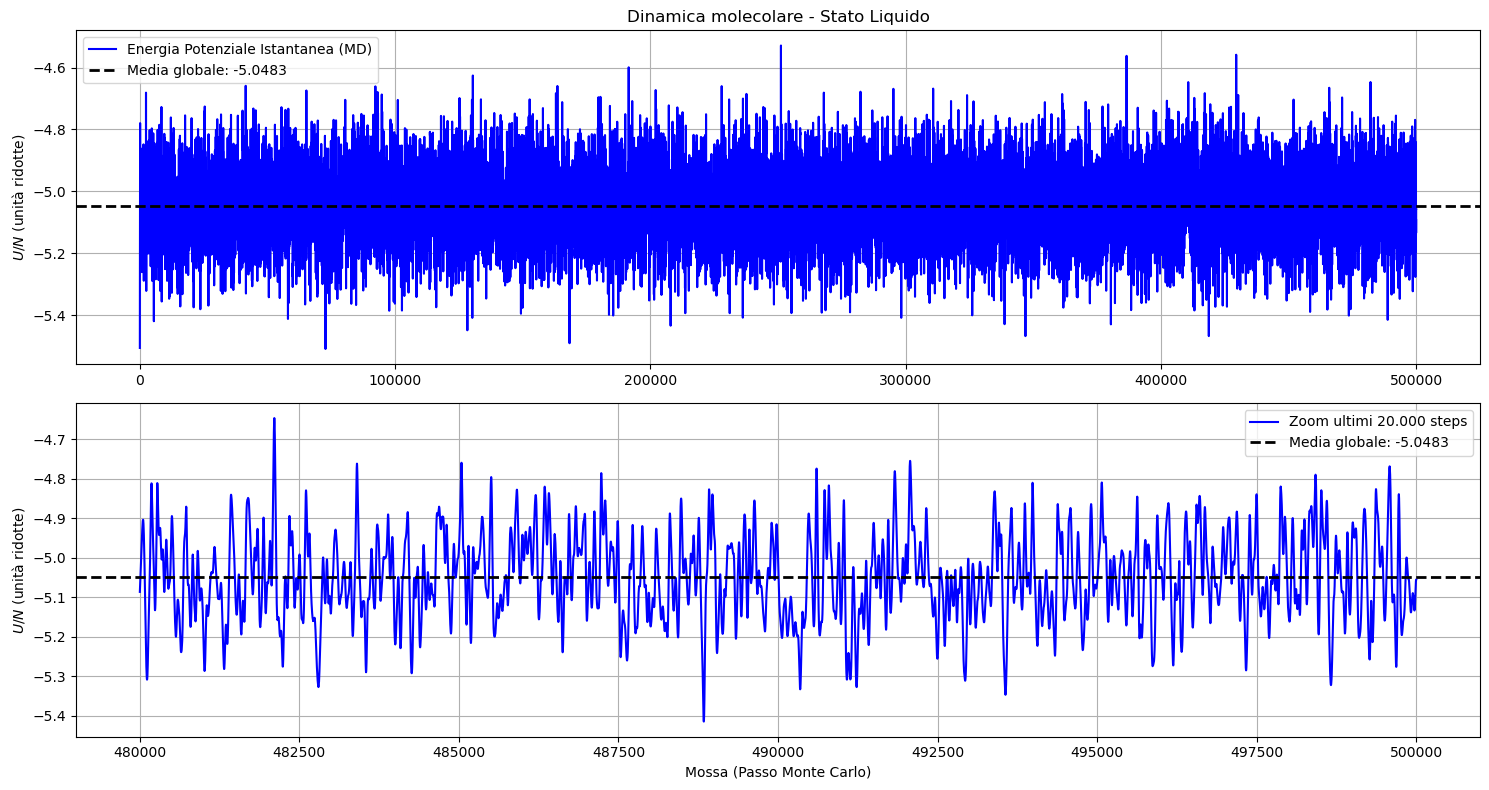

In [117]:
import numpy as np
import matplotlib.pyplot as plt

MD_path = "OUTPUT_MD"
epot_md = np.loadtxt(MC_path + "/potential_energy.dat", usecols=1)
valore_medio = np.mean(epot_md)
steps = np.arange(len(epot_md))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))

ax1.plot(steps, epot_md, label="Energia Potenziale Istantanea (MD)", color="blue")
ax1.axhline(y=valore_medio, color="black", linestyle="--", linewidth=2, label=f"Media globale: {valore_medio:.4f}")
ax1.set_ylabel(r"$U/N$ (unità ridotte)")
ax1.set_title("Dinamica molecolare - Stato Liquido")
ax1.grid(True)
ax1.legend()

zoom_start = -20000
ax2.plot(steps[zoom_start:], epot_md[zoom_start:], label="Zoom ultimi 20.000 steps", color="blue")
ax2.axhline(y=valore_medio, color="black", linestyle="--", linewidth=2, label=f"Media globale: {valore_medio:.4f}")
ax2.set_xlabel("Mossa (Passo Monte Carlo)")
ax2.set_ylabel(r"$U/N$ (unità ridotte)")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

L'ultimo grafico è uno zoom degli ultimi 20.000 passi della grossa simulazione da 500.000 steps. Possiamo notare che i dati siano chiaramente **correlati**, infatti notiamo come ci sia un comportamento dei dati che dipende dalla storia dei dati precendenti. Sono presenti numerose zone in cui i dati si attestano in regioni sopra la media globale, mentre altre zone in cui si attestano sotto. 
Proprio per questo motivo, al fine di capire quanto devono essere lunghi i blocchi delle successive simulazioni è utile calcolare la **funzione di autocorrelazione**, che ci dice circa qual è il tempo di correlazione $\tau_{corr}$, in modo tale che possiamo prendere dei blocchi più grandi. 

<span style="color:red"> **Non richiesto**. </span> Come spiegato precedentemente per essere sicuro della **convergenza** dell'energia potenziale della simulazione a un valore preciso ho plottato il valore della **media progressiva** della simulazione precendente. notiamo anche in questo caso che all'aumentare degli steps della simulazione viene raggiunto un valore di convergenza ben preciso

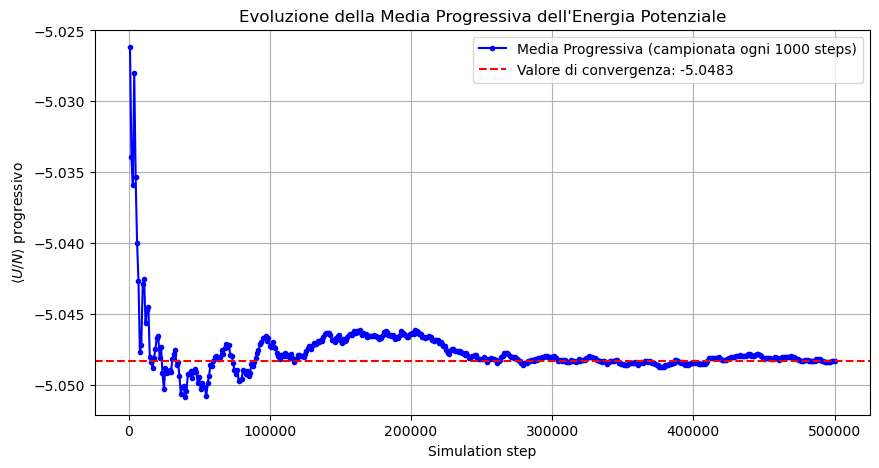

In [14]:
import numpy as np
import matplotlib.pyplot as plt

dati = epot_md  
step_dim = 1000
punti_media = np.arange(step_dim, len(dati) + 1, step_dim)
media_progressiva = []
for n in punti_media:
    media_attuale = np.mean(dati[:n])
    media_progressiva.append(media_attuale)
media_progressiva = np.array(media_progressiva)

plt.figure(figsize=(10, 5))
plt.plot(punti_media, media_progressiva, marker='o', markersize=3, linestyle='-', color='blue', label='Media Progressiva (campionata ogni 1000 steps)')
valore_finale = media_progressiva[-1]
plt.axhline(y=valore_finale, color='red', linestyle='--', label=f'Valore di convergenza: {valore_finale:.4f}')
plt.xlabel("Simulation step")
plt.ylabel(r"$\langle U/N \rangle$ progressivo")
plt.title("Evoluzione della Media Progressiva dell'Energia Potenziale")
plt.grid(True)
plt.legend()
plt.show()

1. <span style="color:red">Once this data has been produced, compute and make pictures with a python script of the autocorrelation functions of $U/N$ to approximately estimate how large the blocks in your simulations should be.
2. Use the same data to study, with a python script, the estimation of the statistical uncertainties of the expectation value of $U/N$ for different size of the blocks in the data blocking technique, from $L=M/N=10$ to $L=5\times 10^3$, being $N$ the number of blocks. <span style="color:red">Make pictures of these statistical uncertainties as a function of $L$.</span> What you observe in the statistical uncertainties after that the block size is large enough (from the point of view of the data blocking technique)?

La **funzione di autocorrelazione** $\chi(t)$ è definita come:

$$\chi(t) = \frac{\frac{1}{t_{\text{max}} - t} \sum_{t'=0}^{t_{\text{max}}-t} m(t')m(t' + t) - \frac{1}{t_{\text{max}} - t} \sum_{t'=0}^{t_{\text{max}}-t} m(t') \times \frac{1}{t_{\text{max}} - t} \sum_{t'=0}^{t_{\text{max}}-t} m(t' + t)}{\frac{1}{t_{\text{max}}} \sum_{t'=0}^{t_{\text{max}}} m^2(t') - \left( \frac{1}{t_{\text{max}}} \sum_{t'=0}^{t_{\text{max}}} m(t') \right)^2}$$

In [90]:
import numpy as np
import matplotlib.pyplot as plt

def autocorrelazione(m, t, t_max):
    
    f1 = 1./(t_max - t)
    f2 = 1./t_max
    m_t_primo = m[0 : t_max - t]
    m_t_piu_t = m[t : t_max]
    m_0_t_max = m[0 : t_max]
    somma1 = f1*np.sum(m_t_primo * m_t_piu_t)
    somma2 = f1*np.sum(m_t_primo)
    somma3 = f1*np.sum(m_t_piu_t)
    somma4 = f2*np.sum(m_0_t_max**2)
    somma5 = f2*np.sum(m_0_t_max)

    return (somma1 - (somma2*somma3))/(somma4 - (somma5*somma5))

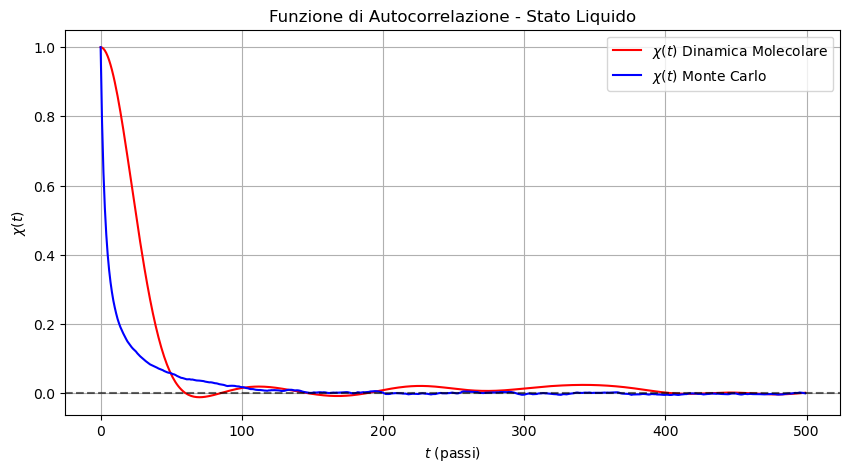

In [128]:
t_max = len(epot_md)
max_lag = 500

chi_valori_md = []
chi_valori_mc = []

for t in range(max_lag):
    valore_chi_md = autocorrelazione(epot_md, t, t_max)
    valore_chi_mc = autocorrelazione(epot_mc, t, t_max)
    chi_valori_md.append(valore_chi_md)
    chi_valori_mc.append(valore_chi_mc)


plt.figure(figsize=(10, 5))
plt.plot(range(max_lag), chi_valori_md, color="red", label=r"$\chi(t)$ Dinamica Molecolare")
plt.plot(range(max_lag), chi_valori_mc, color="blue", label=r"$\chi(t)$ Monte Carlo")
plt.axhline(y=0, color="black", linestyle="--", alpha=0.6)
plt.xlabel("$t$ (passi)")
plt.ylabel(r"$\chi(t)$")
plt.title("Funzione di Autocorrelazione - Stato Liquido")
plt.grid(True)
plt.legend()
plt.show()

A occhio semprerebbe che entrambe le curve perdano ogni tipo di correlazione entro **200 steps**. Ad essere più precisi, riguardo la **dinamica molecolare** possiamo notare come la funzione di autocorrelazione vada a 0 circa in **70 steps**.
Rigurado invece la simulazione **Monte Carlo** la funzione di autocorrelazione ha un decadimento più dolce e lungo e va a zero in circa **150 steps**

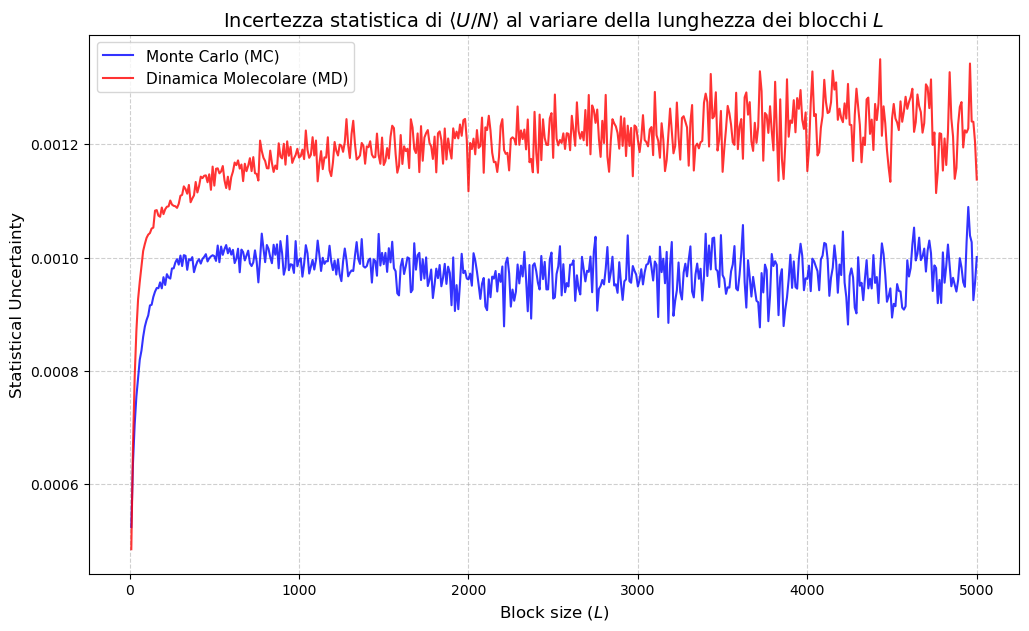

In [137]:
def data_blocking_error(y):
    
    medie_blocchi = np.mean(y, axis=1)
    average = np.mean(medie_blocchi)
    average2 = np.mean(medie_blocchi**2)
    N_blocks = len(y)
    error = np.sqrt((average2 - average**2) / (N_blocks - 1))
    
    return error

errors_mc = np.zeros(len(L_sizes))
errors_md = np.zeros(len(L_sizes))

for i, L in enumerate(L_sizes):
    N_blocks_mc = len(epot_mc) // L # // sta per divisione intera
    data_trimmed_mc = epot_mc[0 : N_blocks_mc * L].reshape((N_blocks_mc, L))
    errors_mc[i] = data_blocking_error(data_trimmed_mc)

for i, L in enumerate(L_sizes):
    N_blocks_md = len(epot_md) // L
    data_trimmed_md = epot_md[0 : N_blocks_md * L].reshape((N_blocks_md, L))
    errors_md[i] = data_blocking_error(data_trimmed_md)

plt.figure(figsize=(12, 7))
plt.plot(L_sizes, errors_mc, linestyle='-', color='blue', label='Monte Carlo (MC)', alpha=0.8)
plt.plot(L_sizes, errors_md, linestyle='-', color='red', label='Dinamica Molecolare (MD)', alpha=0.8)
plt.title('Incertezza statistica di $\langle U/N \\rangle$ al variare della lunghezza dei blocchi $L$', fontsize=14)
plt.xlabel('Block size ($L$)', fontsize=12)
plt.ylabel('Statistical Uncertainty', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

Possiamo notare che all'aumentare della lunghezza dei blocchi il valore della **incertezza statistica** va a **saturare** a un certo valore.
Inoltre va notato che per blocchi piccoli, l'operazione di datablocking **sottostima** l'incertezza statistica. Questo fenomeno è causato dal fatto che i dati quando i blocchi sono troppo piccoli e hanno una lunghezza inferiore al tempo caratteristico di correlazione, sono correlati. Tale correlazione ha come effetto una sottostima dell'errore statistico. Infatti, intuitivamente, quando i dati si trovano in una regione "correlata" in cui abbiamo una sovrastima rispetto alla media, l'incertezza statistica sarà più piccola della reale incertezza statistica se la lughezza dei blocchi fosse maggiore e che quindi andrebbe a tener conto dei dati che fluttuano in altro modo rispetto alla "regione di correlazione precedente".

### Exercise 07.3

<span style="color:red">Include the calculation of the radial distribution function, $g(r)$, as a function of the radial distance $r$ among particles, with $r \in \left[ 0; L/2\right]$ inside the NSL simulator code</span>: average value of $g(r)$ in each block, final average value of $g(r)$ with statistical uncertainties in a separate file.

### Exercise 07.4

By means of your upgraded NSL simulator code, equilibrate and <span style="color:red">perform MC NVT and MD NVE simulations via a Lennard-Jones model</span> of Argon ($\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) in the following conditions:
- liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r_c = 2.5$)

show in pictures the obtained average values and uncertainties for the potential energy per particle, $U/N$, the pressure $P$ and the radial distribution function $g(r)$ in LJ units ... <span style="color:red"> and compare your MC results for these quantities with those obtained via MD NVE simulations in similar thermodynamic conditions.</span>

Per calcolare funzione di distribuzione radiale $g(r)$ bisogna calcolare la distanza relativa tra tutte le possibili coppie di particelle per mappare come si distribuiscono nello spazio.
Per efficienza di calcolo utilizziamo due cicli nidificati da $0$ a $N-1$ e da $i+1$ a $N$ in modo tale da evitare di calcolare la distanza di una particella con se stessa e di tenere conto della distanza tra le coppie di particelle una volta sola. 
All'interno dei cicli calcolo per ciascuna coppia il vettore distanza applicando le condizioni al contorno periodiche (PBC) e ne ricavo la distanza.
In seguito suddivido lo spazio in bin. Dividendo la distanza per la larghezza del singolo bin, eseguo un troncamento intero per individuare il bin in cui far ricadere la misura. Se questo indice è valido, il programma aggiorna l'istogramma incrementando il contatore del bin corrispondente.

Come fatto precendentemente inizio le due simulazioni (MC e MD) con una **fase di equilibrazione** composta da **50.000 steps** partendo da una struttura cristallina **fcc**.
In seguito inizio la vera e propria simulazione con i seguenti dati di input 

### Parametri di Input

<table style="width: 100%; border: none;">
<tr>
<td style="width: 50%; vertical-align: top; border: none;">

**Monte Carlo (NVT)**
<pre>
SIMULATION_TYPE        1       
RESTART                0       
TEMP                   1.9     
NPART                  108    
RHO                    0.8     
R_CUT                  2.5    
DELTA                  0.1   
NBLOCKS                50      
NSTEPS                 3000

ENDINPUT
</pre>

</td>
<td style="width: 50%; vertical-align: top; border: none;">

**Molecular Dynamics (NVE)**
<pre>
SIMULATION_TYPE        0       
RESTART                0       
TEMP                   1.9     
NPART                  108    
RHO                    0.8     
R_CUT                  2.5    
DELTA                  0.001   
NBLOCKS                50      
NSTEPS                 3000

ENDINPUT
</pre>

</td>
</tr>
</table>


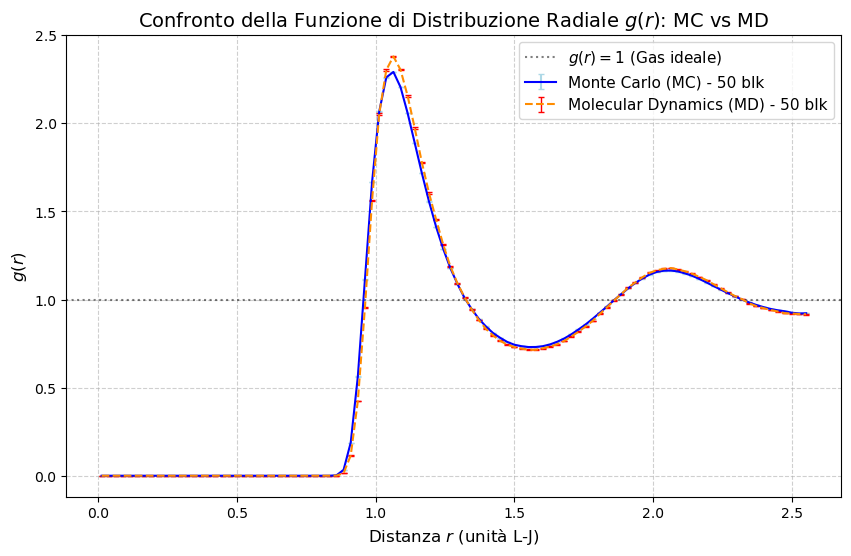

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Percorsi dei file per Monte Carlo (MC) e Dinamica Molecolare (MD)
file_path_mc = "OUTPUT_ARGON_MC/gofr.dat"
file_path_md = "OUTPUT_ARGON_MD/gofr.dat"


data_mc = np.loadtxt(file_path_mc)
elenco_blocchi_mc = data_mc[:, 0]
ultimo_blocco_mc = np.max(elenco_blocchi_mc)
dati_finali_mc = data_mc[elenco_blocchi_mc == ultimo_blocco_mc]

r_mc = dati_finali_mc[:, 2]
g_r_mc = dati_finali_mc[:, 4]
errore_mc = dati_finali_mc[:, 5]


data_md = np.loadtxt(file_path_md)
elenco_blocchi_md = data_md[:, 0]
ultimo_blocco_md = np.max(elenco_blocchi_md)
dati_finali_md = data_md[elenco_blocchi_md == ultimo_blocco_md]

r_md = dati_finali_md[:, 2]
g_r_md = dati_finali_md[:, 4]
errore_md = dati_finali_md[:, 5]


plt.figure(figsize=(10, 6))
plt.errorbar(r_mc, g_r_mc, yerr=errore_mc, fmt='-', color='blue', ecolor='lightblue', elinewidth=1.5, capsize=2,label=f'Monte Carlo (MC) - {int(ultimo_blocco_mc)} blk')
plt.errorbar(r_md, g_r_md, yerr=errore_md, fmt='--', color='darkorange', ecolor='red', elinewidth=1, capsize=2,label=f'Molecular Dynamics (MD) - {int(ultimo_blocco_md)} blk')
plt.title('Confronto della Funzione di Distribuzione Radiale $g(r)$: MC vs MD', fontsize=14)
plt.xlabel('Distanza $r$ (unità L-J)', fontsize=12)
plt.ylabel('$g(r)$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(1.0, color='black', linestyle=':', alpha=0.5, label='$g(r) = 1$ (Gas ideale)')
plt.legend(fontsize=11, loc='upper right')
plt.show()

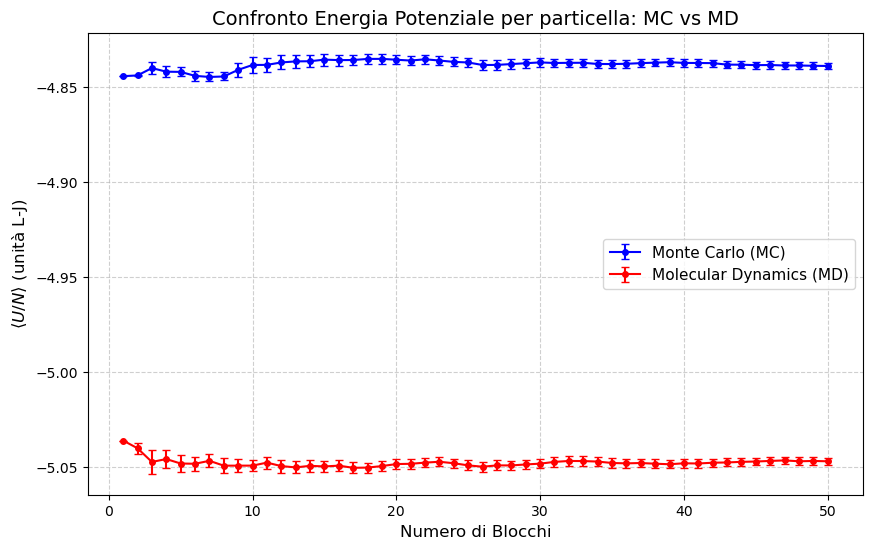

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Percorsi dei file dell'energia potenziale
file_path_mc = "OUTPUT_ARGON_MC/potential_energy.dat"
file_path_md = "OUTPUT_ARGON_MD/potential_energy.dat"


data_mc = np.loadtxt(file_path_mc)
blk_mc = data_mc[:, 0]
epot_mc = data_mc[:, 2]       
errore_mc = data_mc[:, 3]      


data_md = np.loadtxt(file_path_md)
blk_md = data_md[:, 0]
epot_md = data_md[:, 2]       
errore_md = data_md[:, 3]     

plt.figure(figsize=(10, 6))

plt.errorbar(blk_mc, epot_mc, yerr=errore_mc,fmt='-o', markersize=4, color='blue', ecolor='blue', elinewidth=1.5, capsize=3,label='Monte Carlo (MC)')
plt.errorbar(blk_mc, epot_md, yerr=errore_md,fmt='-o', markersize=4, color='red', ecolor='red', elinewidth=1.5, capsize=3,label='Molecular Dynamics (MD)')
plt.title('Confronto Energia Potenziale per particella: MC vs MD', fontsize=14)
plt.xlabel('Numero di Blocchi', fontsize=12)
plt.ylabel(r'$\langle U/N \rangle$ (unità L-J)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='best')
plt.show()

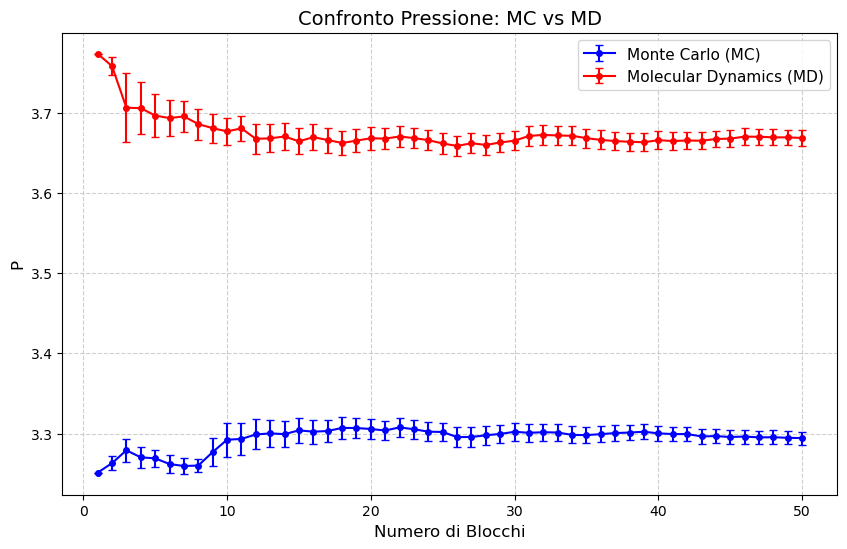

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Percorsi dei file dell'energia potenziale
file_path_mc = "OUTPUT_ARGON_MC/pressure.dat"
file_path_md = "OUTPUT_ARGON_MD/pressure.dat"


data_mc = np.loadtxt(file_path_mc)
blk_mc = data_mc[:, 0]
pressure_mc = data_mc[:, 2]       
errore_mc = data_mc[:, 3]      


data_md = np.loadtxt(file_path_md)
blk_md = data_md[:, 0]
pressure_md = data_md[:, 2]       
errore_md = data_md[:, 3]     

plt.figure(figsize=(10, 6))

plt.errorbar(blk_mc, pressure_mc, yerr=errore_mc,fmt='-o', markersize=4, color='blue', ecolor='blue', elinewidth=1.5, capsize=3,label='Monte Carlo (MC)')
plt.errorbar(blk_mc, pressure_md, yerr=errore_md,fmt='-o', markersize=4, color='red', ecolor='red', elinewidth=1.5, capsize=3,label='Molecular Dynamics (MD)')
plt.title('Confronto Pressione: MC vs MD', fontsize=14)
plt.xlabel('Numero di Blocchi', fontsize=12)
plt.ylabel(r'P', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='best')
plt.show()

### Supplementary activity ... just for your fun!
Note that he following **is not** part of the Numerical Exercise 7; if you had fun with exercises 7.* and you are courious, you could try to repeat exercises 7.2 and 7.4 in the following different thermodynamic conditions:
- solid phase: $\rho^\star = 1.1$, $T^\star = 0.8$ (cut-off radius: $r^\star_c = 2.2$)
- gas phase: $\rho^\star = 0.05$, $T^\star = 1.2$ (cut-off radius: $r^\star_c = 5.0$)